# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
transaksi = pd.read_csv("D:/Submission/bank_transactions_data.csv")
transaksi.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### Struktur Data

In [3]:
transaksi.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
transaksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

- Terdapat 2512 baris data dengan 16 kolom yaitu kolom TransactionID, AccountID, TransactionAmount, TransactionDate, TransactionType, Location, DeviceID, IP Address, MerchantID, Channel, CustomerAge, CustomerOccupation, TransactionDuration, LoginAttempts, AccountBalance, dan PreviousTransactionDate.
- Kolom TransactionID, AccountID, TransactionDate, DeviceID, IP Address, MerchantID, dan PreviousTransactionDate tidak diperlukan dalam analisis clustering.
- Data tidak ada yang kosong/hilang

In [5]:
transaksi.describe(include="all")

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512,2512,2512.000000,2512,2512,2512,2512,2512,2512,2512,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512
unique,2512,495,NaN,2512,2,43,681,592,100,3,NaN,4,NaN,NaN,NaN,360
top,TX000001,AC00362,NaN,2023-04-11 16:29:14,Debit,Fort Worth,D000697,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,1,12,NaN,1,1944,70,9,13,45,868,NaN,657,NaN,NaN,NaN,16
mean,NaN,NaN,297.593778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.673965,NaN,119.643312,1.124602,5114.302966,NaN
std,NaN,NaN,291.946243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.792198,NaN,69.963757,0.602662,3900.942499,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.885000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.370000,NaN
50%,NaN,NaN,211.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.500000,1.000000,4735.510000,NaN
75%,NaN,NaN,414.527500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7678.820000,NaN


- Data tidak ada yang bermasalah

In [ ]:
transaksi = transaksi.drop(columns=['TransactionID', 'AccountID'])
transaksi.head()

,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [7]:
transaksi = transaksi.drop(columns=['TransactionDate', 'DeviceID', 'IP Address', 'MerchantID', 'PreviousTransactionDate'])
transaksi.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70,Doctor,81,1,5112.21
1,376.24,Debit,Houston,ATM,68,Doctor,141,1,13758.91
2,126.29,Debit,Mesa,Online,19,Student,56,1,1122.35
3,184.50,Debit,Raleigh,Online,26,Student,25,1,8569.06
4,13.45,Credit,Atlanta,Online,26,Student,198,1,7429.40


### Analisis Distribusi dan Korelasi

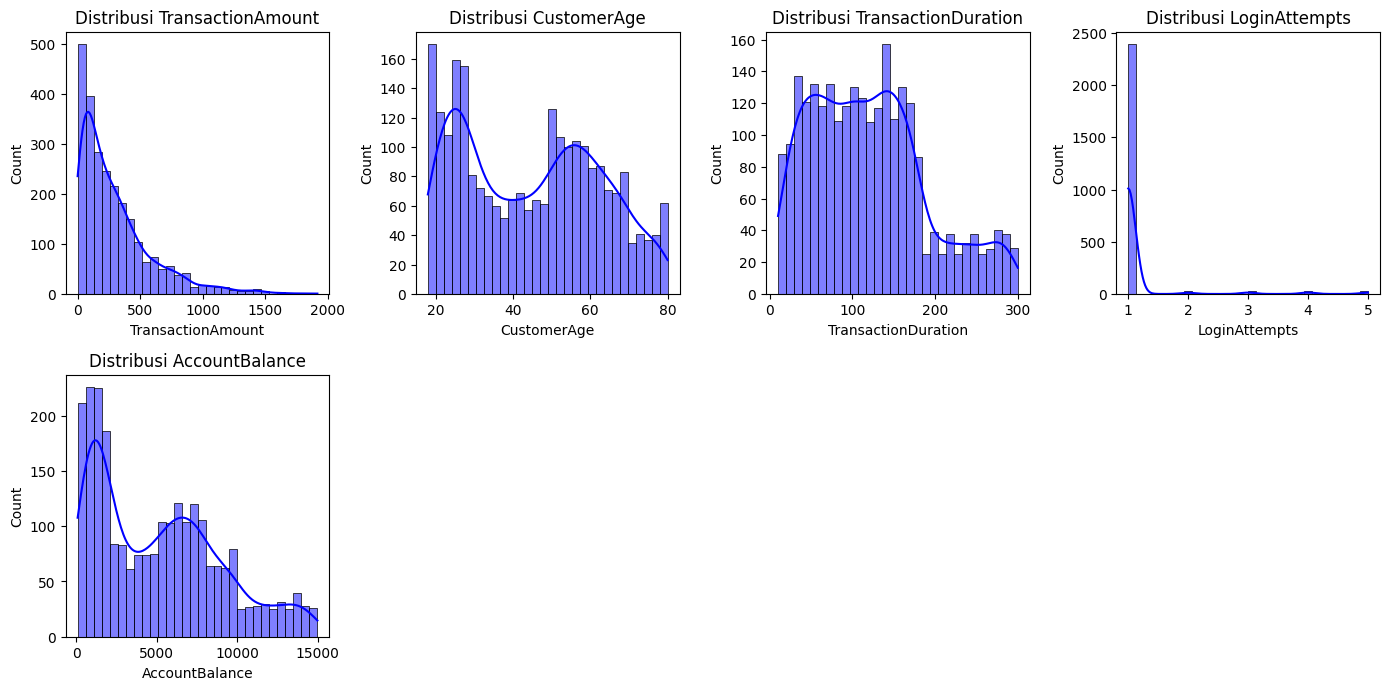

In [8]:
num_features = transaksi.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(transaksi[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

In [9]:
correlation_matrix = num_features.corr()
print(correlation_matrix)

                     TransactionAmount  CustomerAge  TransactionDuration  \
TransactionAmount             1.000000    -0.025616             0.004359   
CustomerAge                  -0.025616     1.000000            -0.017936   
TransactionDuration           0.004359    -0.017936             1.000000   
LoginAttempts                -0.008445     0.007653             0.032639   
AccountBalance               -0.025165     0.319942             0.005577   

                     LoginAttempts  AccountBalance  
TransactionAmount        -0.008445       -0.025165  
CustomerAge               0.007653        0.319942  
TransactionDuration       0.032639        0.005577  
LoginAttempts             1.000000        0.014999  
AccountBalance            0.014999        1.000000  


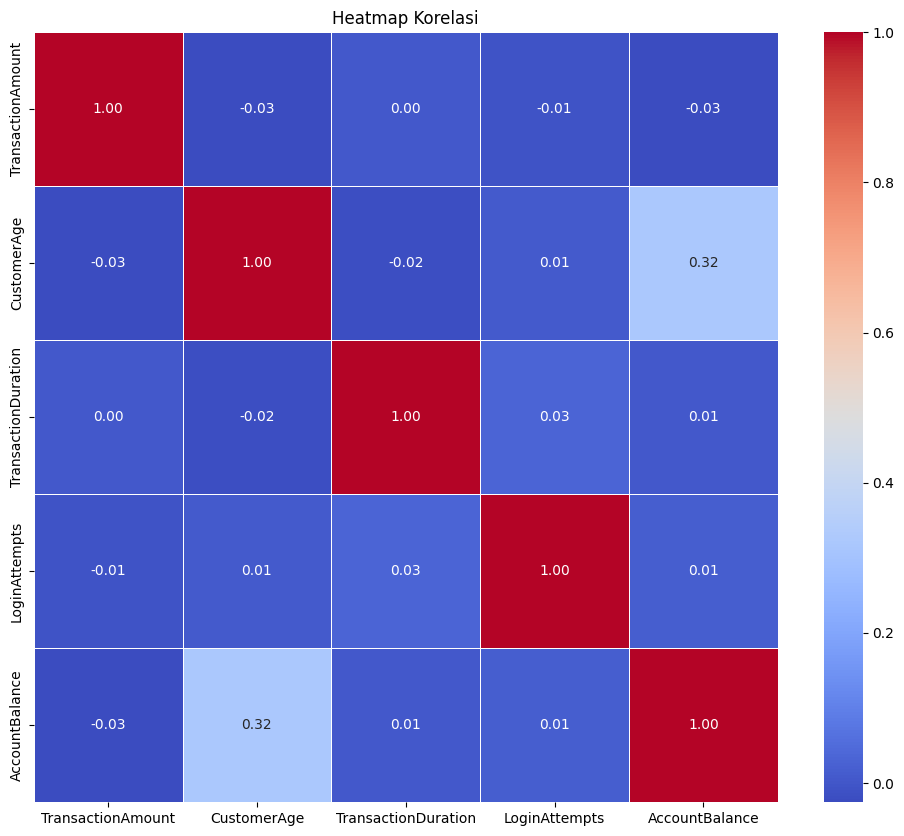

In [10]:
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

### Visualisasi Data

C:\Users\User\AppData\Local\Temp\ipykernel_1992\3104227324.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=transaksi[column], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_1992\3104227324.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=transaksi[column], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_1992\3104227324.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=transaksi[column], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_1992\3104227324.py:7: FutureWarning: 

Passin

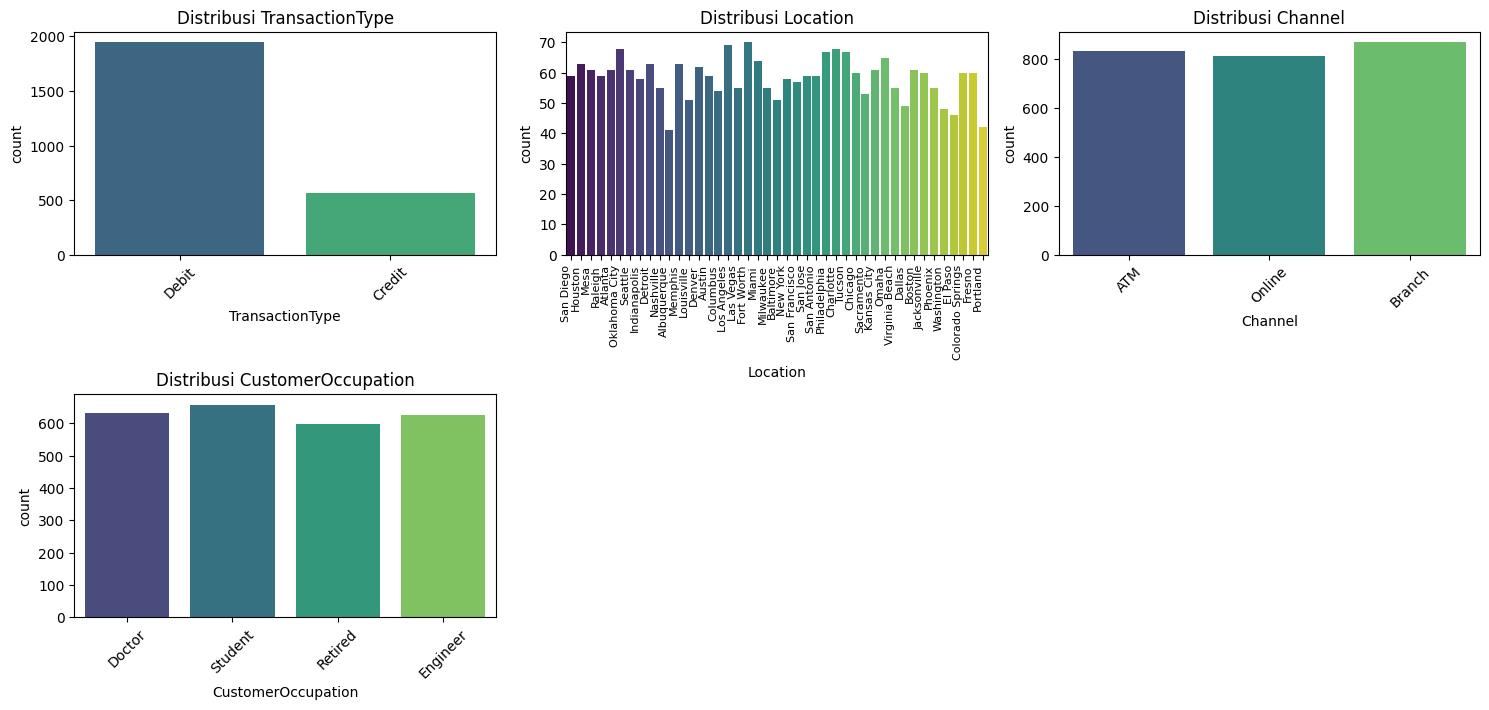

In [14]:
cat_features = transaksi.select_dtypes(include=['object', 'category'])

plt.figure(figsize=(15, 10))

for i, column in enumerate(cat_features.columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=transaksi[column], palette='viridis')

    if column == 'Location':
        plt.xticks(rotation=90, ha='right', fontsize=8)
    else:
        plt.xticks(rotation=45)

    plt.title(f'Distribusi {column}')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [15]:
transaksi.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70,Doctor,81,1,5112.21
1,376.24,Debit,Houston,ATM,68,Doctor,141,1,13758.91
2,126.29,Debit,Mesa,Online,19,Student,56,1,1122.35
3,184.50,Debit,Raleigh,Online,26,Student,25,1,8569.06
4,13.45,Credit,Atlanta,Online,26,Student,198,1,7429.40


### Cek duplikasi data

In [16]:
transaksi.isna().sum()

TransactionAmount      0
TransactionType        0
Location               0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

- Tidak ada duplikasi data

### Normalisasi

In [17]:
transaksi_scaled = transaksi.copy()

numerik_features = transaksi.select_dtypes(include=['float64', 'int64']).columns.tolist()

scaler = MinMaxScaler()
transaksi_scaled[numerik_features] = scaler.fit_transform(transaksi_scaled[numerik_features])

print(transaksi_scaled[['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']].head())


   TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
0           0.007207     0.838710             0.244828            0.0   
1           0.195940     0.806452             0.451724            0.0   
2           0.065680     0.016129             0.158621            0.0   
3           0.096016     0.129032             0.051724            0.0   
4           0.006874     0.129032             0.648276            0.0   

   AccountBalance  
0        0.336832  
1        0.918055  
2        0.068637  
3        0.569198  
4        0.492591  


### Deteksi dan penanganan outlier

In [18]:
numeric_features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

for feature in numeric_features:
    Q1 = transaksi_scaled[feature].quantile(0.25)
    Q3 = transaksi_scaled[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = transaksi_scaled[(transaksi_scaled[feature] < lower_bound) | (transaksi_scaled[feature] > upper_bound)]
  
    print(f"Outlier pada fitur {feature}: {len(outliers)} data")


Outlier pada fitur TransactionAmount: 113 data
Outlier pada fitur CustomerAge: 0 data
Outlier pada fitur TransactionDuration: 0 data
Outlier pada fitur LoginAttempts: 122 data
Outlier pada fitur AccountBalance: 0 data


- Terdapat 113 outlier pada TransactionAmount dan 122 outlier pada LoginAttempts . Karena data miring maka data diganti dengan batas atas dan batas bawah

In [22]:
Q1 = transaksi_scaled['TransactionAmount'].quantile(0.25)
Q3 = transaksi_scaled['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

transaksi_scaled['TransactionAmount'] = np.where(transaksi_scaled['TransactionAmount'] < lower_bound,
                                             lower_bound,
                                             np.where(transaksi_scaled['TransactionAmount'] > upper_bound,
                                                      upper_bound,
                                                      transaksi_scaled['TransactionAmount']))


In [23]:
Q1_new = transaksi_scaled['TransactionAmount'].quantile(0.25)
Q3_new = transaksi_scaled['TransactionAmount'].quantile(0.75)
IQR_new = Q3_new - Q1_new

lower_bound_new = Q1_new - 1.5 * IQR_new
upper_bound_new = Q3_new + 1.5 * IQR_new

outliers_after = transaksi_scaled[(transaksi_scaled['TransactionAmount'] < lower_bound_new) |
                               (transaksi_scaled['TransactionAmount'] > upper_bound_new)]

print(f"Jumlah outlier setelah penggantian: {len(outliers_after)}")

Jumlah outlier setelah penggantian: 0


In [24]:
Q1 = transaksi_scaled['LoginAttempts'].quantile(0.25)
Q3 = transaksi_scaled['LoginAttempts'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

transaksi_scaled['LoginAttempts'] = np.where(transaksi_scaled['LoginAttempts'] < lower_bound,
                                             lower_bound,
                                             np.where(transaksi_scaled['LoginAttempts'] > upper_bound,
                                                      upper_bound,
                                                      transaksi_scaled['LoginAttempts']))

In [25]:
Q1_new = transaksi_scaled['LoginAttempts'].quantile(0.25)
Q3_new = transaksi_scaled['LoginAttempts'].quantile(0.75)
IQR_new = Q3_new - Q1_new

lower_bound_new = Q1_new - 1.5 * IQR_new
upper_bound_new = Q3_new + 1.5 * IQR_new

outliers_after = transaksi_scaled[(transaksi_scaled['LoginAttempts'] < lower_bound_new) |
                               (transaksi_scaled['LoginAttempts'] > upper_bound_new)]

print(f"Jumlah outlier setelah penggantian: {len(outliers_after)}")

Jumlah outlier setelah penggantian: 0


- Sudah tidak ada oulier di data manapun

### Encoding data kategorikal (one hot encoding)

In [27]:
EncodedData = transaksi.copy()

# Lakukan One-Hot Encoding untuk kolom 'TransactionType', 'Location', 'Channel', dan 'CustomerOccupation'
EncodedData = pd.get_dummies(EncodedData, columns=['TransactionType', 'Location', 'Channel','CustomerOccupation'], drop_first=False)

# Pilih kolom numerikal dan kolom hasil encoding
numerical_features = EncodedData.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Gabungkan fitur numerikal dan hasil encoding untuk clustering
encoded_columns = [col for col in EncodedData.columns if col.startswith('TransactionType') 
                   or col.startswith('Location') 
                   or col.startswith('Channel') 
                   or col.startswith('CustomerOccupation')]

# Gabungkan fitur numerikal dan encoded columns
features_for_clustering = numerical_features + encoded_columns

# Ambil data untuk clustering
data_final = EncodedData[features_for_clustering]

scaler = MinMaxScaler()
data_final_scaled = scaler.fit_transform(data_final)

data_final_scaled_df = pd.DataFrame(data_final_scaled, columns=features_for_clustering)

print(data_final_scaled_df.head())

   TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
0           0.007207     0.838710             0.244828            0.0   
1           0.195940     0.806452             0.451724            0.0   
2           0.065680     0.016129             0.158621            0.0   
3           0.096016     0.129032             0.051724            0.0   
4           0.006874     0.129032             0.648276            0.0   

   AccountBalance  TransactionType_Credit  TransactionType_Debit  \
0        0.336832                     0.0                    1.0   
1        0.918055                     0.0                    1.0   
2        0.068637                     0.0                    1.0   
3        0.569198                     0.0                    1.0   
4        0.492591                     1.0                    0.0   

   Location_Albuquerque  Location_Atlanta  Location_Austin  ...  \
0                   0.0               0.0              0.0  ...   
1                 

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [28]:
models = {}
inertia = []
labels_list = {}
range_clusters = range(2, 11)

for i in range_clusters:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_final_scaled)
    inertia.append(kmeans.inertia_)
    models[i] = kmeans  # Simpan model yang sudah dilatih
    labels_list[i] = labels  # Simpan label hasil klasterisasi

for i, val in zip(range_clusters, inertia):
    print(f"Jumlah Klaster: {i}, Inertia: {val}")

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in

Jumlah Klaster: 2, Inertia: 6645.042982613511
Jumlah Klaster: 3, Inertia: 5805.524438259728
Jumlah Klaster: 4, Inertia: 5409.908768178002
Jumlah Klaster: 5, Inertia: 4964.888521843057
Jumlah Klaster: 6, Inertia: 4770.9675562092
Jumlah Klaster: 7, Inertia: 4565.797722862992
Jumlah Klaster: 8, Inertia: 4374.991354448592
Jumlah Klaster: 9, Inertia: 4258.838862047636
Jumlah Klaster: 10, Inertia: 4031.8121556201254


## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.


Silhouette Score untuk setiap jumlah klaster:
Jumlah Klaster: 2, Silhouette Score: 0.1140
Jumlah Klaster: 3, Silhouette Score: 0.1653
Jumlah Klaster: 4, Silhouette Score: 0.1864
Jumlah Klaster: 5, Silhouette Score: 0.1735
Jumlah Klaster: 6, Silhouette Score: 0.1522
Jumlah Klaster: 7, Silhouette Score: 0.1638
Jumlah Klaster: 8, Silhouette Score: 0.1545
Jumlah Klaster: 9, Silhouette Score: 0.1688
Jumlah Klaster: 10, Silhouette Score: 0.1881

Inertia untuk setiap jumlah klaster:
Jumlah Klaster: 2, Inertia: 6645.04
Jumlah Klaster: 3, Inertia: 5805.52
Jumlah Klaster: 4, Inertia: 5409.91
Jumlah Klaster: 5, Inertia: 4964.89
Jumlah Klaster: 6, Inertia: 4770.97
Jumlah Klaster: 7, Inertia: 4565.80
Jumlah Klaster: 8, Inertia: 4374.99
Jumlah Klaster: 9, Inertia: 4258.84
Jumlah Klaster: 10, Inertia: 4031.81


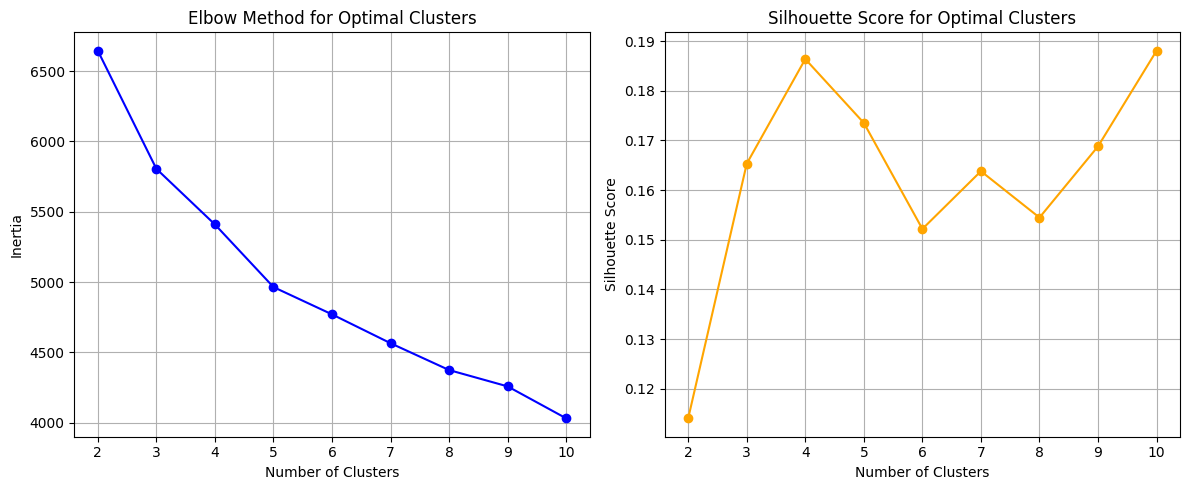

In [29]:
# Inisialisasi tempat menyimpan hasil
models = {}
inertia = []
silhouette_scores = []
labels_list = {}

# Range jumlah klaster yang dicoba
range_clusters = range(2, 11)

# Looping untuk melatih KMeans dengan berbagai jumlah klaster
for i in range_clusters:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_final_scaled)
    
    inertia.append(kmeans.inertia_)
    models[i] = kmeans
    labels_list[i] = labels

    silhouette_avg = silhouette_score(data_final_scaled, labels)
    silhouette_scores.append(silhouette_avg)

print("\nSilhouette Score untuk setiap jumlah klaster:")
for i, val in zip(range_clusters, silhouette_scores):
    print(f"Jumlah Klaster: {i}, Silhouette Score: {val:.4f}")

print("\nInertia untuk setiap jumlah klaster:")
for i, val in zip(range_clusters, inertia):
    print(f"Jumlah Klaster: {i}, Inertia: {val:.2f}")

plt.figure(figsize=(12, 5))

# Elbow Method
plt.subplot(1, 2, 1)
plt.plot(range_clusters, inertia, marker='o', color='blue')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(range_clusters, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [30]:
pca = PCA(n_components=5)
data_pca = pca.fit_transform(data_final_scaled)

print('Explained Variance Ratio:', pca.explained_variance_ratio_)

for i in range(2, 11):
    kmeans_pca = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels_pca = kmeans_pca.fit_predict(data_pca)
    sil_score_pca = silhouette_score(data_pca, labels_pca)
    print(f"Jumlah Klaster: {i}, Silhouette Score (PCA): {sil_score_pca:.4f}")

Explained Variance Ratio: [0.14100174 0.11234083 0.11132504 0.09020205 0.08684571]
Jumlah Klaster: 2, Silhouette Score (PCA): 0.2845
Jumlah Klaster: 3, Silhouette Score (PCA): 0.3385
Jumlah Klaster: 4, Silhouette Score (PCA): 0.3473
Jumlah Klaster: 5, Silhouette Score (PCA): 0.3953
Jumlah Klaster: 6, Silhouette Score (PCA): 0.4171
Jumlah Klaster: 7, Silhouette Score (PCA): 0.4518
Jumlah Klaster: 8, Silhouette Score (PCA): 0.4765
Jumlah Klaster: 9, Silhouette Score (PCA): 0.5175
Jumlah Klaster: 10, Silhouette Score (PCA): 0.5590


- Nilai sihoute score masih terlalu rendah, maka perlu ditingkatkan lagi agar diperoleh nilai terbaiknya

In [31]:
# Inisialisasi
results = []
best_score = -1
best_n_components = 0
best_clusters = 0

# Coba variasi jumlah komponen PCA
for n in range(2, min(len(data_final_scaled[0]), 11)):
    pca = PCA(n_components=n)
    data_pca = pca.fit_transform(data_final_scaled)

    # Coba berbagai jumlah cluster
    for i in range(2, 11):
        kmeans_pca = KMeans(n_clusters=i, random_state=42, n_init=10)
        labels_pca = kmeans_pca.fit_predict(data_pca)
        sil_score_pca = silhouette_score(data_pca, labels_pca)

        # Simpan hasil tiap kombinasi
        results.append({
            "PCA Components": n,
            "Clusters": i,
            "Silhouette Score": round(sil_score_pca, 4)
        })

        # Cek score terbaik
        if sil_score_pca > best_score:
            best_score = sil_score_pca
            best_n_components = n
            best_clusters = i

results_df = pd.DataFrame(results)
print("\nSummary Silhouette Scores:")
print(results_df.sort_values(by="Silhouette Score", ascending=False))

print(f"\nSilhouette Score terbaik: {best_score:.4f}")
print(f"Jumlah Komponen PCA terbaik: {best_n_components}")
print(f"Jumlah Klaster terbaik: {best_clusters}")



Summary Silhouette Scores:
    PCA Components  Clusters  Silhouette Score
17               3        10            0.7618
7                2         9            0.7411
16               3         9            0.7385
6                2         8            0.7353
8                2        10            0.7268
..             ...       ...               ...
36               6         2            0.2084
45               7         2            0.2018
54               8         2            0.1978
63               9         2            0.1914
72              10         2            0.1825

[81 rows x 3 columns]

Silhouette Score terbaik: 0.7618
Jumlah Komponen PCA terbaik: 3
Jumlah Klaster terbaik: 10


- Diperoleh jumlah cluster terbaik yaitu 10

In [33]:
pca_best = PCA(n_components=best_n_components)
data_pca_best = pca_best.fit_transform(data_final_scaled)

kmeans_best = KMeans(n_clusters=best_clusters, random_state=42, n_init=10)
best_labels = kmeans_best.fit_predict(data_pca_best)

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

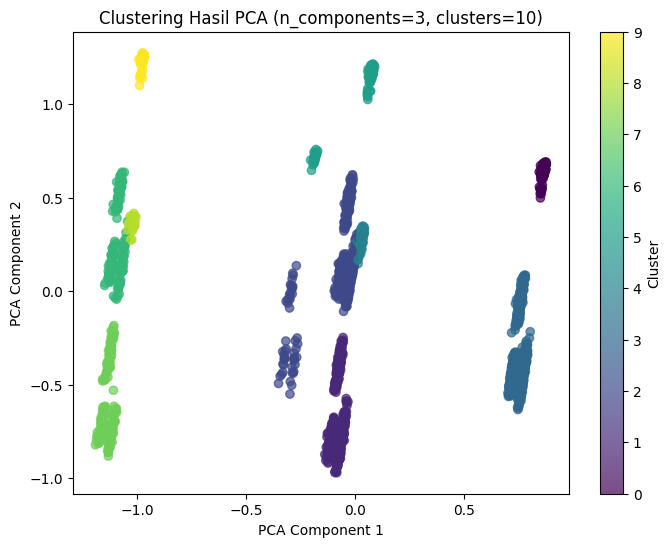

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(data_pca_best[:, 0], data_pca_best[:, 1], c=best_labels, cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Clustering Hasil PCA (n_components={best_n_components}, clusters={best_clusters})')
plt.colorbar(label='Cluster')
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [35]:
# Buat DataFrame hasil scaling
data_final_clustered = pd.DataFrame(data_final_scaled, columns=features_for_clustering)
data_final_clustered['Cluster'] = best_labels  

# Ambil ulang TransactionType, Location, Channel, dan CustomerOccupation dari data asli
data_final_clustered['TransactionType'] = transaksi['TransactionType'].values
data_final_clustered['Location'] = transaksi['Location'].values
data_final_clustered['Channel'] = transaksi['Channel'].values
data_final_clustered['CustomerOccupation'] = transaksi['CustomerOccupation'].values

# Gabungkan ke data asli
final_transaksi_clustered = transaksi.copy()
final_transaksi_clustered['Cluster'] = data_final_clustered['Cluster']

# Atur ulang urutan kolom agar 'Cluster' di ujung
cols = list(final_transaksi_clustered.columns)
cols.remove('Cluster')
cols.append('Cluster')
final_transaksi_clustered = final_transaksi_clustered[cols]

pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.colheader_justify', 'center')
pd.set_option('display.float_format', '{:.2f}'.format)

print(final_transaksi_clustered.head(10))


   TransactionAmount TransactionType    Location    Channel  CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance  Cluster
0        14.09             Debit          San Diego     ATM      70             Doctor                81                1            5112.21        3   
1       376.24             Debit            Houston     ATM      68             Doctor               141                1           13758.91        3   
2       126.29             Debit               Mesa  Online      19            Student                56                1            1122.35        5   
3       184.50             Debit            Raleigh  Online      26            Student                25                1            8569.06        5   
4        13.45            Credit            Atlanta  Online      26            Student               198                1            7429.40        9   
5        92.15             Debit      Oklahoma City     ATM      18            Stu

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [36]:
transaksi_scaled = transaksi.copy()
numerik_features = transaksi.select_dtypes(include=['float64', 'int64']).columns.tolist()
scaler = MinMaxScaler()
transaksi_scaled[numerik_features] = scaler.fit_transform(transaksi_scaled[numerik_features])
transaksi_scaled[numerik_features] = scaler.inverse_transform(transaksi_scaled[numerik_features])
print(transaksi_scaled.head())


   TransactionAmount TransactionType  Location  Channel  CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance
0        14.09             Debit      San Diego     ATM    70.00            Doctor              81.00             1.00           5112.21   
1       376.24             Debit        Houston     ATM    68.00            Doctor             141.00             1.00          13758.91   
2       126.29             Debit           Mesa  Online    19.00           Student              56.00             1.00           1122.35   
3       184.50             Debit        Raleigh  Online    26.00           Student              25.00             1.00           8569.06   
4        13.45            Credit        Atlanta  Online    26.00           Student             198.00             1.00           7429.40   


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [37]:
print(final_transaksi_clustered['Cluster'].value_counts())

Cluster
3    561
2    460
1    455
0    199
6    190
7    189
5    180
4    162
8     62
9     54
Name: count, dtype: int64


Dari 2512 data:
- Cluster 3 menjadi cluster yang isinya paling banyak yaitu 561 data 
- Cluster 2 berisi 460 data
- Cluster 1 berisi 455 data
- Cluster 0 berisi 199 data
- Cluster 6 berisi 190 data
- Cluster 7 berisi 189 data
- Cluster 5 berisi 180 data
- Cluster 4 berisi 162 data
- Cluster 8 berisi 62 data
- Cluster 9 menjadi cluster yang isinya paling rendah yaitu 54 data

In [38]:
cluster_summary = final_transaksi_clustered.groupby('Cluster')[numerik_features].mean()
print(cluster_summary)

         TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  AccountBalance
Cluster                                                                                    
0             329.31          22.78            125.57             1.13          1576.44    
1             277.60          51.33            120.90             1.12          6558.69    
2             293.02          51.44            118.12             1.12          6146.49    
3             299.07          52.99            120.71             1.12          6320.87    
4             273.88          23.15            105.31             1.08          1676.53    
5             320.58          23.19            125.59             1.12          1407.25    
6             289.51          53.38            117.23             1.19          6763.10    
7             306.27          53.87            116.05             1.14          6205.91    
8             348.71          23.42            117.24             1.19          

- Cluster 0 memiliki rata-rata jumlah transaksi tertinggi, termuda, durasi transaksi terlama ke dua, login attempts terbanyak, dan saldo akun hampir terendah.
- Cluster 1 memiliki rata-rata jumlah transaksi hampir terendah, rata-rata usia tertua ke lima, durasi transaksi terlama ke tiga, login attempts terbanyak ke tiga, dan saldo akun terbanyak ke dua.
- Cluster 2 memiliki rata-rata jumlah transaksi tertinggi ke tujuh, tertua ke empat, durasi transaksi terlama ke delapan, login attempts terbanyak ke tiga, dan saldo akun tertinggi ke lima.
- Cluster 3 memiliki rata-rata jumlah transaksi tertinggi ke enam, tertua ke empat, durasi transaksi terlama ke empat, login attempts terbanyak ke tiga, dan saldo akun tertinggi ke tiga.
- Cluster 4 memiliki rata-rata jumlah transaksi terendah, rata-rata usia tertua ke delapan, durasi transaksi terendah, login attempts hampir paling sedikit, dan saldo akun terbanyak ke tujuh.
- Cluster 5 memiliki rata-rata jumlah transaksi tertinggi ke tiga, rata-rata usia tertua ke tujuh, durasi transaksi terlama ke tiga, login attempts terbanyak ke tiga, dan saldo akun hampir terendah.
- Cluster 6 memiliki rata-rata jumlah transaksi tertinggi ke delapan, rata-rata hampi tertua, durasi transaksi terlama ke delapan, login attempts terbanyak, dan saldo akun terbanyak.
- Cluster 7 memiliki rata-rata jumlah transaksi tertinggi ke lima, rata-rata usia tertua, durasi transaksi terlama hampir terendah, login attempts hampir terbanyak, dan saldo akun terbanyak ke empat.
- Cluster 8 memiliki rata-rata jumlah transaksi tertinggi, rata-rata usia tertua ke enam, durasi transaksi terlama ke tujuh, login attempts terbanyak, dan saldo akun terendah.
- Cluster 9 memiliki rata-rata jumlah transaksi tertinggi ke tiga, rata-rata usia hampir termuda, durasi transaksi terlama, login attempts paling sedikit, dan saldo akun terbanyak ke enam.

In [40]:
for col in ['TransactionType', 'Location']:
    print(final_transaksi_clustered.groupby(['Cluster', col]).size().unstack().fillna(0))

TransactionType  Credit  Debit
Cluster                       
0                  0.00 199.00
1                  0.00 455.00
2                 50.00 410.00
3                  0.00 561.00
4                  0.00 162.00
5                 23.00 157.00
6                190.00   0.00
7                189.00   0.00
8                 62.00   0.00
9                 54.00   0.00
Location  Albuquerque  Atlanta  Austin  Baltimore  Boston  Charlotte  Chicago  Colorado Springs  Columbus  Dallas  ...  Raleigh  Sacramento  San Antonio  San Diego  San Francisco  San Jose  Seattle  Tucson  Virginia Beach  Washington
Cluster                                                                                                            ...                                                                                                                   
0            3.00       5.00     2.00     4.00      8.00     7.00      6.00          3.00          5.00     4.00   ...   4.00       3.00        4.00        1.00

In [41]:
for col in ['Channel', 'CustomerOccupation']:
    print(final_transaksi_clustered.groupby(['Cluster', col]).size().unstack().fillna(0))

Channel   ATM   Branch  Online
Cluster                       
0       199.00    0.00    0.00
1         0.00  455.00    0.00
2        50.00    0.00  410.00
3       561.00    0.00    0.00
4         0.00  162.00    0.00
5        23.00    0.00  157.00
6         0.00    0.00  190.00
7         0.00  189.00    0.00
8         0.00   62.00    0.00
9         0.00    0.00   54.00
CustomerOccupation  Doctor  Engineer  Retired  Student
Cluster                                               
0                     0.00     0.00     0.00   199.00 
1                   162.00   157.00   136.00     0.00 
2                   148.00   174.00   138.00     0.00 
3                   198.00   174.00   189.00     0.00 
4                     0.00     0.00     0.00   162.00 
5                     0.00     0.00     0.00   180.00 
6                    66.00    59.00    65.00     0.00 
7                    57.00    61.00    71.00     0.00 
8                     0.00     0.00     0.00    62.00 
9                     0

### **Analisis Transaction Type**
- Cluster 0 di dominasi oleh tipe transaksi debit
- Cluster 1 di dominasi oleh tipe transaksi debit
- Cluster 2 di dominasi oleh tipe transaksi debit namun juga ada sedikit transaksi credit
- Cluster 3 di dominasi oleh tipe transaksi debit
- Cluster 4 di dominasi oleh tipe transaksi debit
- Cluster 5 di dominasi oleh tipe transaksi debit namun juga ada sedikit transaksi credit
- Cluster 6 di dominasi oleh tipe transaksi credit
- Cluster 7 di dominasi oleh tipe transaksi credit
- Cluster 8 di dominasi oleh tipe transaksi credit
- Cluster 9 di dominasi oleh tipe transaksi credit

### **Analisis Location**
- Lokasi transaksi tersebar cukup merata di segala daerah kecuali cluster 8 yang tidak ada  di wilayah (Charlotte, Chicago, Seattle) dan cluster 9 yang tidak ada di wilayah (Albuquerque, Charlotte, Dallas, Sacramento, Washington).

### **Analisis Channel**
- Cluster 0 di dominasi di ATM
- Cluster 1 di dominasi di cabang
- Cluster 2 di dominasi online dan ada yang sedikit di ATM
- Cluster 3 di dominasi di ATM
- Cluster 4 di dominasi di cabang
- Cluster 5 di dominasi online dan ada sedikit yang di ATM
- Cluster 6 di dominasi online
- Cluster 7 di dominasi di cabang
- Cluster 8 di dominasi di cabang
- Cluster 9 di dominasi online

### **Analisis Customer Occupation**
- Cluster 0 di dominasi student
- Cluster 1 di dominasi doctor, engineer, dan retired
- Cluster 2 di dominasi doctor, engineer, dan retired
- Cluster 3 di dominasi doctor, engineer, dan retired
- Cluster 4 di dominasi student
- Cluster 5 di dominasi student
- Cluster 6 di dominasi doctor, engineer, dan retired
- Cluster 7 di dominasi doctor, engineer, dan retired
- Cluster 8 di dominasi student
- Cluster 9 di dominasi student

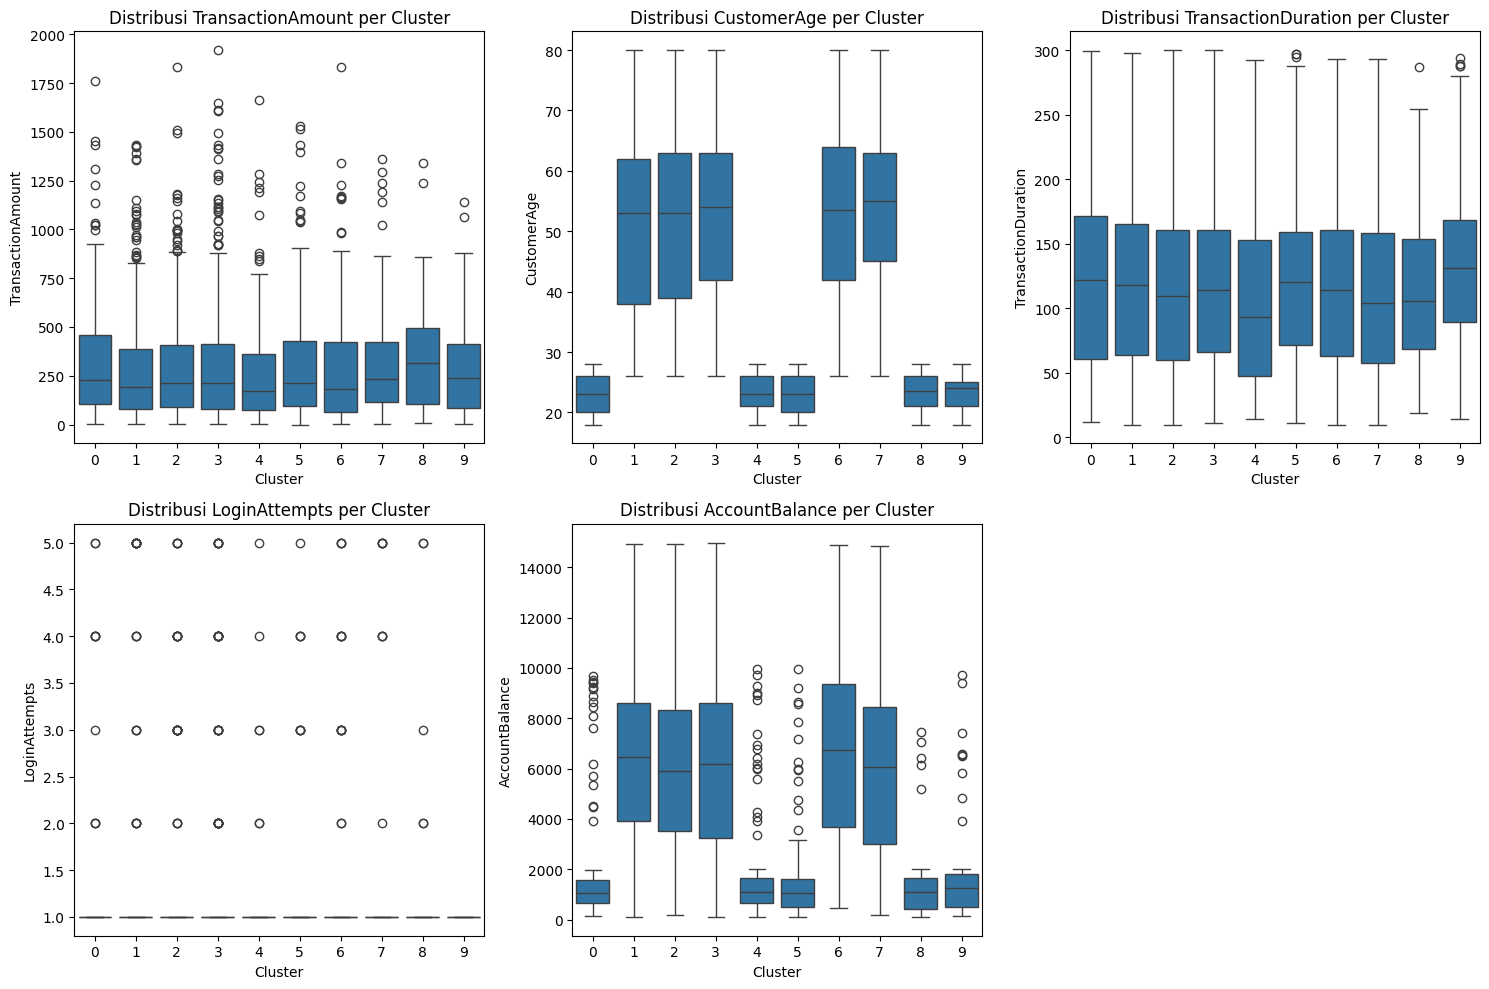

In [42]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerik_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=final_transaksi_clustered, x='Cluster', y=col)
    plt.title(f'Distribusi {col} per Cluster')
    plt.tight_layout()

plt.show()

- Dari boxplot di atas terdapat banyak otlier pada transaction amount, customer age, login attempts, account balace, dan sedikit outlier di transaction duration. Meskipun ada banyak outlier namun kita tidak bisa menghapus outlier tersebut karena outlier data transaksi di bank sangat penting untuk mengetahui transaksi mana yang janggal.

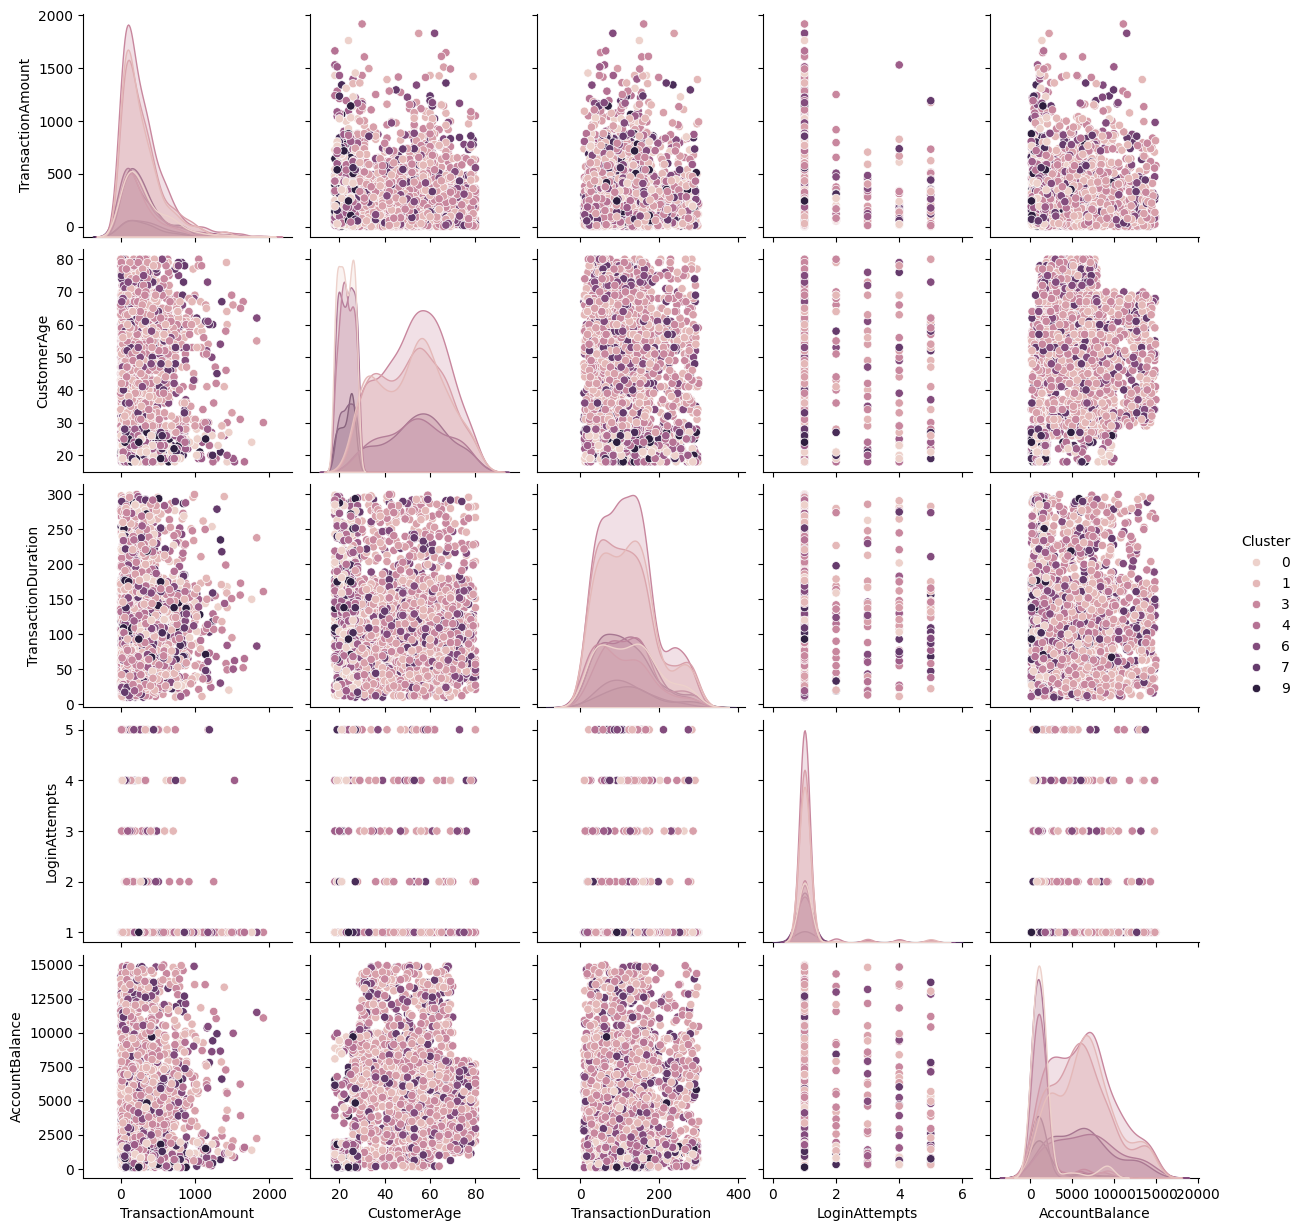

In [43]:
plt.show()
sns.pairplot(final_transaksi_clustered, hue='Cluster', diag_kind='kde')
plt.show()

# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0:
- **Rata-rata TransactionAmount:** 329,31  
- **Rata-rata CustomerAge:** 22,78
- **Rata-rata TransactionDuration:** 125,57
- **Rata-rata LoginAttempts:** 1,13
- **Rata-rata AccountBalance:** 1576,44
- **TransactionType:** Debit
- **Location:** Seluruh wilayah
- **Channel:** ATM
- **CustomerOccupation:** Student
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi, termuda, durasi transaksi terlama ke dua, login attempts terbanyak, saldo akun hampir terendah, menggunakan tipe transaksi debit di ATM, berlokasi menyebar di seluruh wilayah, dan pekerjaannya student.

## Cluster 1:
- **Rata-rata TransactionAmount:** 277,6 
- **Rata-rata CustomerAge:** 51,33
- **Rata-rata TransactionDuration:** 120,9
- **Rata-rata LoginAttempts:** 1,12
- **Rata-rata AccountBalance:** 6558,69
- **TransactionType:** Debit
- **Location:** Seluruh wilayah
- **Channel:** Branch
- **CustomerOccupation:** doctor, engineer, retired
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi hampir terendah, rata-rata usia tertua ke lima, durasi transaksi terlama ke tiga, login attempts terbanyak ke tiga, saldo akun terbanyak ke dua, menggunakan tipe transaksi debit di cabang, berlokasi menyebar di seluruh wilayah, dan pekerjaannya doctor, engineer, retired.


## Cluster 2:
- **Rata-rata TransactionAmount:** 293,02 
- **Rata-rata CustomerAge:** 51,44
- **Rata-rata TransactionDuration:** 118,12
- **Rata-rata LoginAttempts:** 1,12
- **Rata-rata AccountBalance:** 6146,49
- **TransactionType:** Debit dan Credit
- **Location:** Seluruh wilayah
- **Channel:** ATM dan Online
- **CustomerOccupation:** doctor, engineer, retired
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi ke tujuh, tertua ke empat, durasi transaksi terlama ke delapan, login attempts terbanyak ke tiga, saldo akun tertinggi ke lima, menggunakan tipe transaksi debit dan credit di ATM dan online, berlokasi menyebar di seluruh wilayah, dan pekerjaannya doctor, engineer, retired.

## Cluster 3:
- **Rata-rata TransactionAmount:** 299,07 
- **Rata-rata CustomerAge:** 52,99
- **Rata-rata TransactionDuration:** 120,71
- **Rata-rata LoginAttempts:** 1,12
- **Rata-rata AccountBalance:** 6320,87
- **TransactionType:** Debit
- **Location:** Seluruh wilayah
- **Channel:** ATM
- **CustomerOccupation:** doctor, engineer, retired
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi ke enam, tertua ke empat, durasi transaksi terlama ke empat, login attempts terbanyak ke tiga, saldo akun tertinggi ke tiga, menggunakan tipe transaksi debit di ATM, berlokasi menyebar di seluruh wilayah, dan pekerjaannya doctor, engineer, retired.

## Cluster 4:
- **Rata-rata TransactionAmount:** 273,88 
- **Rata-rata CustomerAge:** 23,15
- **Rata-rata TransactionDuration:** 105,31
- **Rata-rata LoginAttempts:** 1,08
- **Rata-rata AccountBalance:** 1676,53
- **TransactionType:** Debit
- **Location:** Seluruh wilayah
- **Channel:** Branch
- **CustomerOccupation:** student
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi terendah, rata-rata usia tertua ke delapan, durasi transaksi terendah, login attempts hampir paling sedikit, dan saldo akun terbanyak ke tujuh, menggunakan tipe transaksi debit di cabang, berlokasi menyebar di seluruh wilayah, dan pekerjaannya student.

## Cluster 5:
- **Rata-rata TransactionAmount:** 320,58 
- **Rata-rata CustomerAge:** 23,19
- **Rata-rata TransactionDuration:** 125,59
- **Rata-rata LoginAttempts:** 1,12
- **Rata-rata AccountBalance:** 1407,25
- **TransactionType:** Debit dan credit
- **Location:** Seluruh wilayah
- **Channel:** ATM dan online
- **CustomerOccupation:** student
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi ke tiga, rata-rata usia tertua ke tujuh, durasi transaksi terlama ke tiga, login attempts terbanyak ke tiga, saldo akun hampir terendah, menggunakan tipe transaksi debit dan credit di ATM dan online, berlokasi menyebar di seluruh wilayah, dan pekerjaannya student.

## Cluster 6:
- **Rata-rata TransactionAmount:** 289,51 
- **Rata-rata CustomerAge:** 53,38
- **Rata-rata TransactionDuration:** 117,23
- **Rata-rata LoginAttempts:** 1,19
- **Rata-rata AccountBalance:** 6763,1
- **TransactionType:** Credit
- **Location:** Seluruh wilayah
- **Channel:** Online
- **CustomerOccupation:** doctor, engineer, retired
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi ke delapan, rata-rata hampi tertua, durasi transaksi terlama ke delapan, login attempts terbanyak, saldo akun terbanyak, menggunakan tipe transaksi credit di online, berlokasi menyebar di seluruh wilayah, dan pekerjaannya doctor, engineer, retired.

## Cluster 7:
- **Rata-rata TransactionAmount:** 306,27 
- **Rata-rata CustomerAge:** 53,87
- **Rata-rata TransactionDuration:** 116,05
- **Rata-rata LoginAttempts:** 1,14
- **Rata-rata AccountBalance:** 6205,91
- **TransactionType:** Credit
- **Location:** Seluruh wilayah
- **Channel:** Branch
- **CustomerOccupation:** doctor, engineer, retired
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi ke lima, rata-rata usia tertua, durasi transaksi terlama hampir terendah, login attempts hampir terbanyak, saldo akun terbanyak ke empat, menggunakan tipe transaksi credit di cabang, berlokasi menyebar di seluruh wilayah, dan pekerjaannya doctor, engineer, retired.

## Cluster 8:
- **Rata-rata TransactionAmount:** 348,71 
- **Rata-rata CustomerAge:** 23,42
- **Rata-rata TransactionDuration:** 117,24
- **Rata-rata LoginAttempts:** 1,19
- **Rata-rata AccountBalance:** 1400,71
- **TransactionType:** Credit
- **Location:** Seluruh wilayah kecuali Charlotte, Chicago, Seattle
- **Channel:** Branch
- **CustomerOccupation:** student
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi, rata-rata usia tertua ke enam, durasi transaksi terlama ke tujuh, login attempts terbanyak, saldo akun terendah, menggunakan tipe transaksi credit di cabang, berlokasi menyebar di seluruh wilayah kecuali wilayah (Charlotte, Chicago, Seatle), dan pekerjaannya student.

## Cluster 9:
- **Rata-rata TransactionAmount:** 306,67 
- **Rata-rata CustomerAge:** 23,07
- **Rata-rata TransactionDuration:** 136,02
- **Rata-rata LoginAttempts:** 1
- **Rata-rata AccountBalance:** 1966,1
- **TransactionType:** Credit
- **Location:** Seluruh wilayah kecuali (Albuquerque, Charlotte, Dallas, Sacramento, Washington)
- **Channel:** Online
- **CustomerOccupation:** student
- **Analisis:** Cluster ini mencakup customer bank dengan rata-rata jumlah transaksi tertinggi ke tiga, rata-rata usia hampir termuda, durasi transaksi terlama, login attempts paling sedikit, saldo akun terbanyak ke enam, menggunakan tipe transaksi credit di online, berlokasi menyebar di seluruh wilayah kecuali (Albuquerque, Charlotte, Dallas, Sacramento, Washington), dan pekerjaannya student.


# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [44]:
final_transaksi_clustered.to_csv("final_transaksi_clustered.csv", index=False)